In [8]:
%matplotlib inline
from nansat import Nansat
import numpy as np
from openwind.wind_data import fetch_era5_data, preprocess_wind_data
from datetime import timedelta
import matplotlib.pyplot as plt
import urllib3
urllib3.disable_warnings(urllib3.exceptions.InsecureRequestWarning)


In [2]:
# Step 1: Define search parameters (time and coordinates) to find ERA5 field
# In case of collocation with Sentinel-1 data these parameters can be extracted from the 
# Sentinel-1 product metadata.

# Read a Sentinel-1 L1 GRD product using Nansat
s1_frame = Nansat('S1A_IW_GRDH_1SDV_20220110T173429_20220110T173454_041401_04EC3B_31E4.nc')

In [5]:
s1_lons, s1_lats = s1_frame.get_geolocation_grids()
central_lon = np.nanmean(s1_lons)
central_lat = np.nanmean(s1_lats)
s1_time = s1_frame.time_coverage_start
s1_time = s1_time if s1_time.minute <= 30 else s1_time + timedelta(hours=1)

In [6]:
# Find and download ERA5 data
era5_uri = fetch_era5_data(s1_time, central_lat, central_lon, '/src/.devcontainer/')

>> Downloading /src/.devcontainer/ERA5_20220110T1800.nc


2024-03-05 07:55:47,984 INFO Welcome to the CDS
2024-03-05 07:55:47,984 INFO Sending request to https://cds.climate.copernicus.eu/api/v2/resources/reanalysis-era5-single-levels
2024-03-05 07:55:48,291 INFO Request is completed
2024-03-05 07:55:48,291 INFO Downloading https://download-0021.copernicus-climate.eu/cache-compute-0021/cache/data3/adaptor.mars.internal-1709569199.530703-22069-18-e9efccd9-efeb-4c75-8698-e7c6493799fd.nc to /src/.devcontainer/ERA5_20220110T1800.nc (8.2K)
2024-03-05 07:55:48,655 INFO Download rate 22.6K/s


In [3]:
# Step 1: Define search parameters (time and coordinates) to find ERA5 field
# In case of collocation with Sentinel-1 data these parameters can be extracted from the 
# Sentinel-1 product metadata.

# Read a Sentinel-1 L1 GRD product using Nansat
s1_frame = Nansat('/src/.devcontainer/S1A_IW_GRDH_1SDV_20220110T173429_20220110T173454_041401_04EC3B_31E4.SAFE')
# In order to speed up the processing we will resample the Sentinel-1 product to a pixel size of about 200 m
s1_frame.resize(0.05, resample_alg=1)

0.05

In [4]:
s1_lons, s1_lats = s1_frame.get_geolocation_grids()
central_lon = np.nanmean(s1_lons)
central_lat = np.nanmean(s1_lats)

In [5]:
s1_time = s1_frame.time_coverage_start
s1_time = s1_time if s1_time.minute <= 30 else s1_time + timedelta(hours=1)

In [6]:
# Find and download ERA5 data
era5_uri = fetch_era5_data(s1_time, central_lat, central_lon, '/src/.devcontainer/')

>> Downloading /src/.devcontainer/ERA5_20220110T1800.nc


2022-09-29 07:21:52,828 INFO Welcome to the CDS
2022-09-29 07:21:52,834 INFO Sending request to https://cds.climate.copernicus.eu/api/v2/resources/reanalysis-era5-single-levels
2022-09-29 07:21:53,044 INFO Request is completed
2022-09-29 07:21:53,048 INFO Downloading https://download-0001-clone.copernicus-climate.eu/cache-compute-0001/cache/data1/adaptor.mars.internal-1664359637.4650042-4907-10-a34c7353-d42c-4042-be15-d603029f21ff.nc to /src/.devcontainer/ERA5_20220110T1800.nc (8.2K)
2022-09-29 07:21:53,798 INFO Download rate 11K/s


In [10]:
# Derive wind speed and direction from the model
wind_spd, wind_dir = preprocess_wind_data(era5_uri, dst_geometry=s1_frame)

>> Reading /src/.devcontainer/ERA5_20220110T1800.nc


Warning 1: Latitude grid not spaced evenly.  Setting projection for grid spacing is within 0.1 degrees threshold.
Warning 1: Latitude grid not spaced evenly.  Setting projection for grid spacing is within 0.1 degrees threshold.
Warning 1: Latitude grid not spaced evenly.  Setting projection for grid spacing is within 0.1 degrees threshold.
/opt/conda/lib/python3.11/site-packages/nansat-1.6.0-py3.11-linux-x86_64.egg/nansat/mappers/mapper_netcdf_cf.py:393: UserWarning: GDAL cannot determine the dataset projection - using Nansat spatial reference WKT, assuming a regular longitude/latitude grid
  warnings.warn('GDAL cannot determine the dataset projection - using Nansat ' \
Warning 1: Latitude grid not spaced evenly.  Setting projection for grid spacing is within 0.1 degrees threshold.
Warning 1: Latitude grid not spaced evenly.  Setting projection for grid spacing is within 0.1 degrees threshold.
Warning 1: Latitude grid not spaced evenly.  Setting projection for grid spacing is within 0.

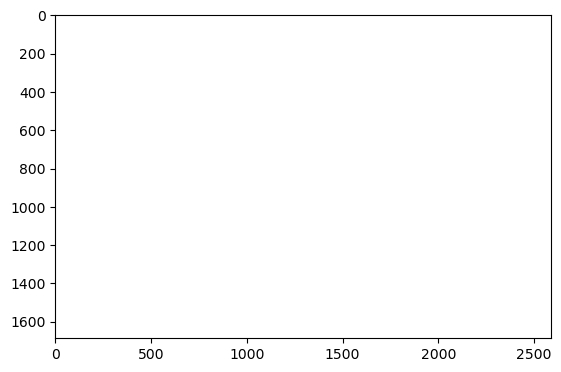

In [12]:
%matplotlib inline
plt.imshow(wind_spd)

PosixPath('/src/.devcontainer/ERA5_20220110T1800.nc')

In [39]:
n = Nansat(str(era5_uri), )

Warning 1: Latitude grid not spaced evenly.  Setting projection for grid spacing is within 0.1 degrees threshold.
Warning 1: Latitude grid not spaced evenly.  Setting projection for grid spacing is within 0.1 degrees threshold.
Warning 1: Latitude grid not spaced evenly.  Setting projection for grid spacing is within 0.1 degrees threshold.
/opt/conda/lib/python3.11/site-packages/nansat-1.6.0-py3.11-linux-x86_64.egg/nansat/mappers/mapper_netcdf_cf.py:393: UserWarning: GDAL cannot determine the dataset projection - using Nansat spatial reference WKT, assuming a regular longitude/latitude grid
  warnings.warn('GDAL cannot determine the dataset projection - using Nansat ' \
Warning 1: Latitude grid not spaced evenly.  Setting projection for grid spacing is within 0.1 degrees threshold.
Warning 1: Latitude grid not spaced evenly.  Setting projection for grid spacing is within 0.1 degrees threshold.
Warning 1: Latitude grid not spaced evenly.  Setting projection for grid spacing is within 0.

In [29]:
n

----------------------------------------
/src/.devcontainer/ERA5_20220110T1800.nc----------------------------------------
Mapper: genericBand : 1 u10
  add_offset: 5.155404631859009
  colormap: jet
  dataType: 6
  long_name: 10 metre U wind component
  minmax: 0 1
  missing_value: -32767
  name: u10
  NETCDF_DIM_time: 1069674
  scale_factor: 0.0002087263942879923
  short_name: fy_frac
  SourceBand: 1
  SourceFilename: NETCDF:"/src/.devcontainer/ERA5_20220110T1800.nc":u10
  standard_name: fraction_of_first_year_ice
  units: m s**-1
  wkv: 
  _FillValue: -32767
Band : 2 v10
  add_offset: 1.10276189159718
  colormap: jet
  dataType: 6
  long_name: 10 metre V wind component
  minmax: 0 1
  missing_value: -32767
  name: v10
  NETCDF_DIM_time: 1069674
  scale_factor: 0.0002066550380628843
  short_name: fy_frac
  SourceBand: 1
  SourceFilename: NETCDF:"/src/.devcontainer/ERA5_20220110T1800.nc":v10
  standard_name: fraction_of_first_year_ice
  units: m s**-1
  wkv: 
  _FillValue: -32767
------

In [25]:
n.reproject(s1_frame)

Warning 1: Latitude grid not spaced evenly.  Setting projection for grid spacing is within 0.1 degrees threshold.
Warning 1: Latitude grid not spaced evenly.  Setting projection for grid spacing is within 0.1 degrees threshold.
Warning 1: Latitude grid not spaced evenly.  Setting projection for grid spacing is within 0.1 degrees threshold.


In [23]:
lo, la = n.get_geolocation_grids()

In [31]:
from nansat import Domain

In [32]:
d = Domain.from_lonlat(lo, la)

In [33]:
d

Domain:[41 x 41]
----------------------------------------
Projection(gcps):
GEOGCS["WGS 84",
    DATUM["WGS_1984",
        SPHEROID["WGS 84",6378137,298.257223563]],
    PRIMEM["Greenwich",0],
    UNIT["degree",0.0174532925199433]]
----------------------------------------
Corners (lon, lat):
	 ( 12.30, -28.25)  ( 22.55, -28.25)
	 ( 12.30, -38.51)  ( 22.55, -38.51)

In [34]:
los, las = s1_frame.get_geolocation_grids()

In [35]:
d1 = Domain.from_lonlat(los, las)

In [36]:
d1

Domain:[2590 x 1687]
----------------------------------------
Projection(gcps):
GEOGCS["WGS 84",
    DATUM["WGS_1984",
        SPHEROID["WGS 84",6378137,298.257223563]],
    PRIMEM["Greenwich",0],
    UNIT["degree",0.0174532925199433]]
----------------------------------------
Corners (lon, lat):
	 ( 15.85, -32.95)  ( 18.50, -32.31)
	 ( 16.32, -34.44)  ( 19.02, -33.79)

In [40]:
n1 = Nansat.from_domain(d)

In [42]:
n1.add_bands[n['v10']]

Signature: n1.add_bands(arrays, parameters=None, nomem=False)
Docstring:
Add bands from numpy arrays with metadata.

Create VRT object which contains VRT and RAW binary file and append it
to self.vrt.band_vrts

Parameters
-----------
arrays : list of ndarrays
    new band data. Shape should be equal to shape
parameters : list of dict
    band metadata: wkv, name, etc. (or for several bands)
nomem : bool
    saves the vrt to a tempfile on disk?

Notes
-----
Creates VRT object with VRT-file and RAW-file. Adds band to the self.vrt.

Examples
--------
    >>> n.add_bands([array1, array2]) # add new bands, keep in memory
File:      /opt/conda/lib/python3.11/site-packages/nansat-1.6.0-py3.11-linux-x86_64.egg/nansat/nansat.py
Type:      method

In [41]:
n1.reproject(d)

RuntimeError: Missing one of rasterXSize, rasterYSize or bands on VRTDataset.